In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from tensorflow.keras.datasets import mnist

In [ ]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Concatenate train and test data and labels
x = np.concatenate((x_train, x_test), axis=0)
y = np.concatenate((y_train, y_test), axis=0)

# Reshape the image data to be 2D (n_samples, n_features)
x_flat = x.reshape(x.shape[0], -1)

# Create a single DataFrame
df = pd.DataFrame(x_flat)
df['label'] = y
df.head()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,label
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9


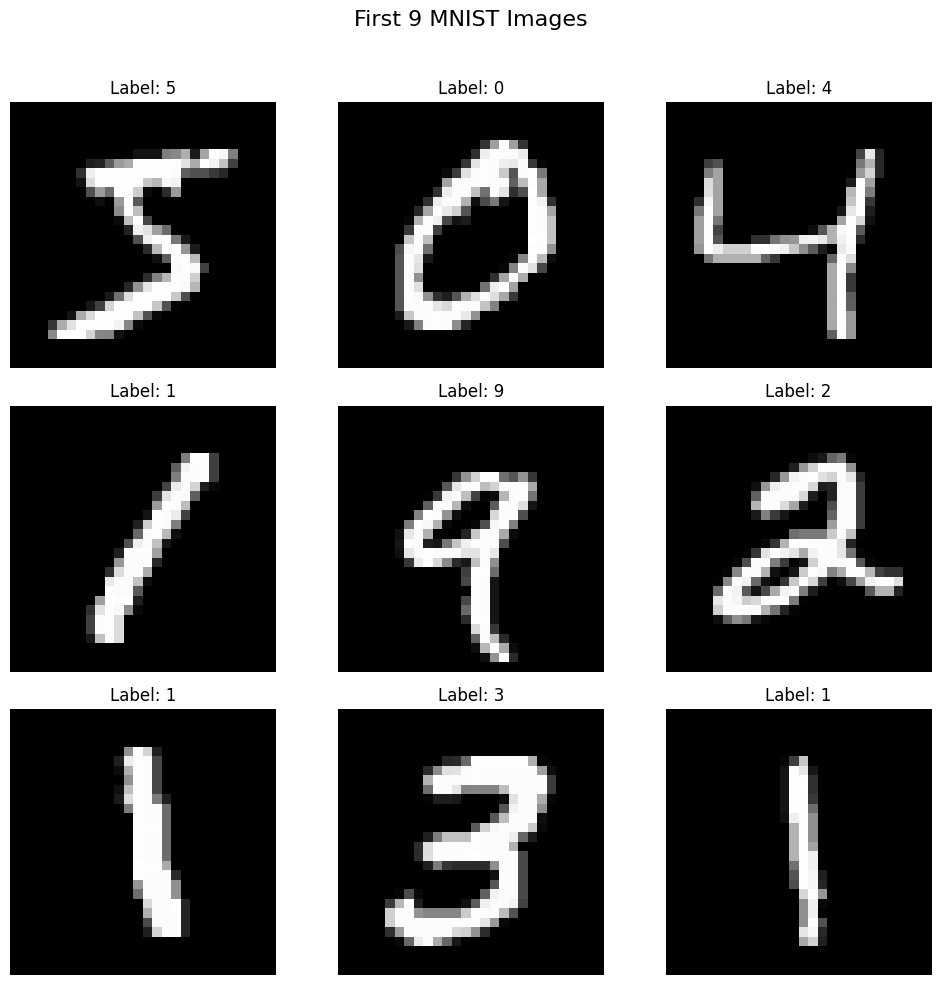

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle("First 9 MNIST Images", fontsize=16)

for i, ax in enumerate(axes.flat):
    img = df.iloc[i, :-1].values.reshape(28, 28)
    label = df.iloc[i, -1]

    ax.imshow(img, cmap='gray')
    ax.axis('off')
    ax.set_title(f"Label: {label}")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
X = df.drop('label', axis=1).values / 255.0
y = df['label'].values

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

In [ ]:
class CustomDataset(Dataset):

  def __init__(self, features, labels):

    # Convert to PyTorch tensors
    self.features = torch.tensor(features, dtype=torch.float32).reshape(-1,1,28,28)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [ ]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

In [ ]:
class MyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Instantiate model
model = MyCNN().to(device)

In [ ]:
# Loss function
criterion = nn.CrossEntropyLoss()
# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
epochs = 20
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct_train = 0
    total_train = 0

    for batch_features, batch_labels in train_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

        # Forward pass
        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)

        # Backward pass & optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_features.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += batch_labels.size(0)
        correct_train += (predicted == batch_labels).sum().item()

    avg_train_loss = running_loss / len(train_dataset)
    train_acc = correct_train / total_train

    model.eval()
    val_loss_total = 0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for batch_features, batch_labels in test_loader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            outputs = model(batch_features)
            loss = criterion(outputs, batch_labels)

            val_loss_total += loss.item() * batch_features.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += batch_labels.size(0)
            correct_val += (predicted == batch_labels).sum().item()

    avg_val_loss = val_loss_total / len(test_dataset)
    val_acc = correct_val / total_val

    # Store metrics
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc*100:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc*100:.2f}%")

Epoch 1/20 | Train Loss: 0.2011, Train Acc: 94.23% | Val Loss: 0.0480, Val Acc: 98.65%
Epoch 2/20 | Train Loss: 0.0860, Train Acc: 97.76% | Val Loss: 0.0480, Val Acc: 98.83%
Epoch 3/20 | Train Loss: 0.0645, Train Acc: 98.36% | Val Loss: 0.0496, Val Acc: 98.83%
Epoch 4/20 | Train Loss: 0.0555, Train Acc: 98.61% | Val Loss: 0.0413, Val Acc: 98.91%
Epoch 5/20 | Train Loss: 0.0483, Train Acc: 98.73% | Val Loss: 0.0392, Val Acc: 98.97%
Epoch 6/20 | Train Loss: 0.0412, Train Acc: 98.92% | Val Loss: 0.0395, Val Acc: 98.99%
Epoch 7/20 | Train Loss: 0.0402, Train Acc: 98.93% | Val Loss: 0.0380, Val Acc: 99.08%
Epoch 8/20 | Train Loss: 0.0372, Train Acc: 99.03% | Val Loss: 0.0401, Val Acc: 99.21%
Epoch 9/20 | Train Loss: 0.0356, Train Acc: 99.15% | Val Loss: 0.0364, Val Acc: 99.10%
Epoch 10/20 | Train Loss: 0.0307, Train Acc: 99.20% | Val Loss: 0.0473, Val Acc: 98.97%
Epoch 11/20 | Train Loss: 0.0276, Train Acc: 99.28% | Val Loss: 0.0522, Val Acc: 99.01%
Epoch 12/20 | Train Loss: 0.0300, Train A

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        outputs = model(batch_features)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_labels.cpu().numpy())

# Accuracy
final_acc = accuracy_score(all_labels, all_preds)
print(f"Final Test Accuracy: {final_acc*100:.2f}%")

# Classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds))


Final Test Accuracy: 99.09%

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1035
           1       1.00      0.99      1.00      1182
           2       0.99      0.99      0.99      1048
           3       0.99      0.99      0.99      1071
           4       0.99      0.98      0.99      1024
           5       0.99      0.99      0.99       947
           6       0.99      0.99      0.99      1031
           7       0.99      0.99      0.99      1094
           8       0.99      0.98      0.99      1024
           9       0.97      0.99      0.98      1044

    accuracy                           0.99     10500
   macro avg       0.99      0.99      0.99     10500
weighted avg       0.99      0.99      0.99     10500



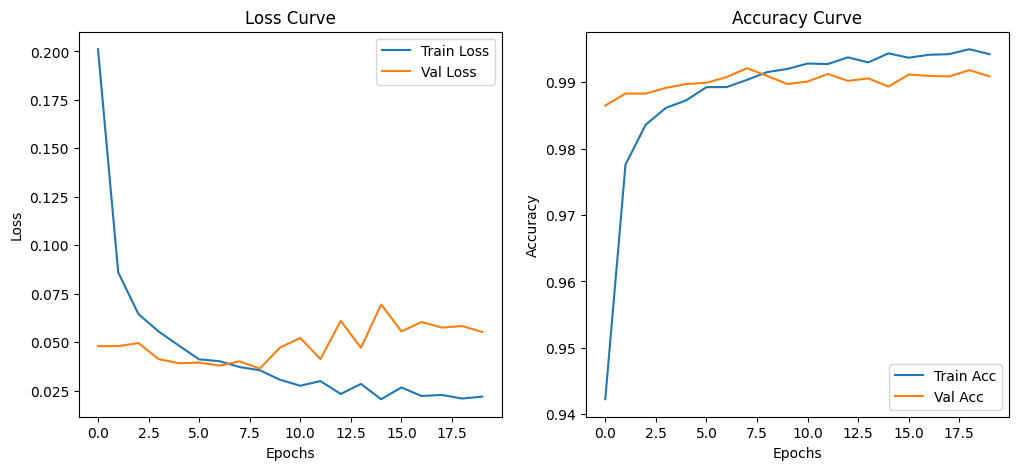

In [ ]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(train_accuracies, label='Train Acc')
plt.plot(val_accuracies, label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()